# 01 · Base Gold e qualidade dos dados

Este notebook abre o projeto da Fase 3. O objetivo aqui não é modelar ainda, e sim garantir que a base sobre a qual tudo vai ser construído é real, íntegra e bem entendida.

Na Fase 2 a camada Gold foi desenhada e provisionada, mas o indicador e as metas acabaram simulados, porque o microdado só saía da Base dos Dados via BigQuery com billing. O Inep passou a publicar direto as planilhas de resultado e meta por município (2023, 2024 e 2025) e, em agosto de 2025, os microdados no grão de aluno. O primeiro passo desta fase foi recompor a Gold no mesmo contrato de esquema, agora com dado real, e acrescentar a tabela `fato_aluno`.

O que este notebook verifica:

1. o que existe em cada tabela da Gold e em que grão;
2. cobertura: quantos municípios e alunos aparecem por ano;
3. checagens de qualidade: chaves, faixas, consistência entre o cálculo próprio e o número oficial do Inep;
4. as bases analíticas (ABT) de município e de aluno, com o alinhamento temporal que evita leakage;
5. o que fica decidido para a EDA e a modelagem.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.abt import carregar_abt_aluno
from src.visualization.estilo import aplicar_estilo, salvar, fmt_pct, AZUL, LARANJA, CINZA, CORES_REGIAO
from src.visualization.rotulos import rotulo

aplicar_estilo()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
GOLD = Path("data/gold")
PROCESSED = Path("data/processed")

## 1. As tabelas da Gold

O contrato é o da Fase 2: uma dimensão de município, uma tabela fato no grão ano x município x rede e os marts de indicador por município, evolução temporal e comparação por UF. As metas ganharam tabelas próprias em formato longo (na fonte elas vêm em formato largo, uma coluna por ano até 2030) e a tabela `fato_aluno` é nova.

In [2]:
tabelas = {
    "dim_municipio": "um município",
    "fato_aluno": "um aluno listado para a prova, presente ou não",
    "fato_alfabetizacao": "ano x município x rede, calculado dos microdados",
    "indicador_municipio": "ano x município, série oficial da rede municipal",
    "metas_municipio": "município x ano da meta (2024 a 2030)",
    "evolucao_temporal": "ano x município, com o ano anterior",
    "comparacao_meta_uf": "ano x UF (e Brasil), indicador e Saeb",
    "metas_uf": "UF x ano da meta",
}
gold = {nome: pd.read_parquet(GOLD / f"{nome}.parquet") for nome in tabelas}
resumo = pd.DataFrame(
    {
        "linhas": {n: len(df) for n, df in gold.items()},
        "colunas": {n: df.shape[1] for n, df in gold.items()},
        "grao": tabelas,
        "tamanho_mb": {n: round((GOLD / f"{n}.parquet").stat().st_size / 1e6, 2) for n in tabelas},
    }
)
resumo

,linhas,colunas,grao,tamanho_mb
dim_municipio,5570,6,um município,0.07
fato_aluno,4343352,11,"um aluno listado para a prova, presente ou não",25.04
fato_alfabetizacao,13110,15,"ano x município x rede, calculado dos microdados",0.32
indicador_municipio,16528,16,"ano x município, série oficial da rede municipal",0.34
metas_municipio,38334,3,município x ano da meta (2024 a 2030),0.23
evolucao_temporal,16528,8,"ano x município, com o ano anterior",0.20
comparacao_meta_uf,136,8,"ano x UF (e Brasil), indicador e Saeb",0.01
metas_uf,194,3,UF x ano da meta,0.00


In [3]:
dim = gold["dim_municipio"]
fato = gold["fato_alfabetizacao"]
indicador = gold["indicador_municipio"]
metas = gold["metas_municipio"]
alunos = gold["fato_aluno"]
uf = gold["comparacao_meta_uf"]

indicador.head()

,ano,id_municipio,nome_municipio,sigla_uf,id_uf,nome_uf,nome_regiao,qtd_avaliados,qtd_alfabetizados,media_proficiencia,indicador_pct,nivel,participacao_pct,meta_municipio,atingiu_meta,gap_meta_pp
0,2023,1100015,Alta Floresta D'Oeste,RO,11,Rondônia,Norte,NaN,NaN,NaN,64.55,3.0,89.37,NaN,<NA>,NaN
1,2023,1100023,Ariquemes,RO,11,Rondônia,Norte,NaN,NaN,NaN,62.30,3.0,89.79,NaN,<NA>,NaN
2,2023,1100031,Cabixi,RO,11,Rondônia,Norte,NaN,NaN,NaN,69.10,3.0,90.48,NaN,<NA>,NaN
3,2023,1100049,Cacoal,RO,11,Rondônia,Norte,NaN,NaN,NaN,62.51,3.0,84.44,NaN,<NA>,NaN
4,2023,1100056,Cerejeiras,RO,11,Rondônia,Norte,NaN,NaN,NaN,58.53,2.0,92.12,NaN,<NA>,NaN


## 2. Cobertura

O Indicador Criança Alfabetizada é medido pela avaliação estadual aplicada em cada UF, na rede pública. A planilha oficial traz o resultado da rede municipal de cada município (a meta é pactuada com o município), e os microdados trazem os alunos das redes municipal e estadual. Duas perguntas importam: quantos municípios têm resultado em cada ano, e quantos alunos estão por trás desses percentuais.

In [4]:
cobertura = (
    indicador.groupby("ano")
    .agg(
        municipios_com_resultado=("indicador_pct", "count"),
        municipios_com_meta=("meta_municipio", "count"),
        participacao_media=("participacao_pct", "mean"),
        indicador_medio=("indicador_pct", "mean"),
    )
    .round(1)
)
cobertura["pct_dos_municipios_brasileiros"] = (100 * cobertura["municipios_com_resultado"] / 5570).round(1)
cobertura

,municipios_com_resultado,municipios_com_meta,participacao_media,indicador_medio,pct_dos_municipios_brasileiros
ano,,,,,
2023,5357,0,89.7,60.4,96.2
2024,5446,5463,91.0,62.8,97.8
2025,5485,5439,93.0,71.9,98.5


In [5]:
por_ano = alunos.groupby("ano").agg(
    alunos_listados=("id_aluno", "size"),
    presentes=("presente", "sum"),
    escolas=("id_escola", "nunique"),
    municipios=("id_municipio", "nunique"),
    ufs=("sigla_uf", "nunique"),
)
por_ano["taxa_presenca_pct"] = (100 * por_ano["presentes"] / por_ano["alunos_listados"]).round(1)
presentes = alunos[(alunos["presente"] == 1) & (alunos["preencheu"] == 1)]
por_ano["alfabetizados_pct_bruto"] = (100 * presentes.groupby("ano")["alfabetizado"].mean()).round(1)
por_ano

,alunos_listados,presentes,escolas,municipios,ufs,taxa_presenca_pct,alfabetizados_pct_bruto
ano,,,,,,,
2024,2120560,1852788,42497,5519,26,87.4,59.8
2025,2222792,1969921,43644,5556,27,88.6,66.3


Em 2024 uma UF (Roraima) não aparece nos microdados; em 2025 as 27 estão presentes. A taxa de presença gira em torno de 88%, e é a régua do que o indicador mede: o percentual oficial é calculado sobre os presentes com prova preenchida. Os ausentes ficam registrados em `fato_aluno` com `alfabetizado = 0`, mas fora do denominador. Essa é uma decisão do Inep que eu mantenho na Gold e que precisa ser respeitada na modelagem, senão o modelo aprende a "prever ausência" em vez de alfabetização.

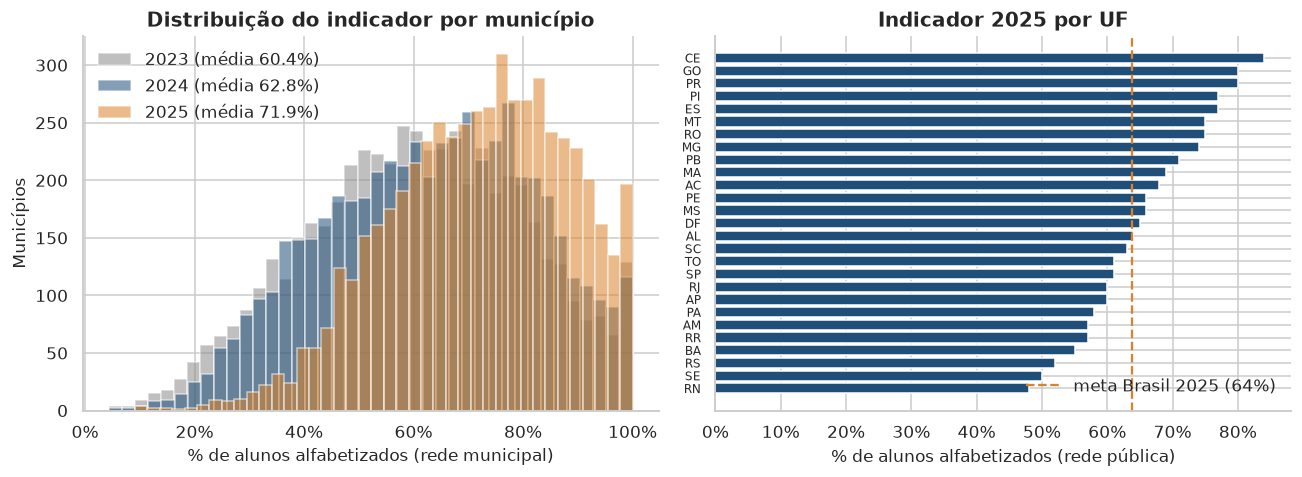

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ano, cor in zip([2023, 2024, 2025], [CINZA, AZUL, LARANJA]):
    serie = indicador.loc[indicador["ano"] == ano, "indicador_pct"].dropna()
    axes[0].hist(serie, bins=40, alpha=0.55, color=cor, label=f"{ano} (média {serie.mean():.1f}%)")
axes[0].set_title("Distribuição do indicador por município")
axes[0].set_xlabel("% de alunos alfabetizados (rede municipal)")
axes[0].set_ylabel("Municípios")
axes[0].legend()
fmt_pct(axes[0])

ordem = uf[(uf["fonte"] == "indicador") & (uf["ano"] == 2025) & (uf["sigla_uf"] != "BR")].sort_values("indicador_pct")
axes[1].barh(ordem["sigla_uf"], ordem["indicador_pct"], color=AZUL)
meta_br = uf[(uf["sigla_uf"] == "BR") & (uf["ano"] == 2025) & (uf["fonte"] == "indicador")]["meta_uf"].iloc[0]
axes[1].axvline(meta_br, color=LARANJA, ls="--", label=f"meta Brasil 2025 ({meta_br:.0f}%)")
axes[1].set_title("Indicador 2025 por UF")
axes[1].set_xlabel("% de alunos alfabetizados (rede pública)")
axes[1].tick_params(axis="y", labelsize=8)
axes[1].legend(loc="lower right")
fmt_pct(axes[1])
salvar(fig, "01_distribuicao_indicador_e_uf")
plt.show()

Dois pontos já saltam aos olhos e vão orientar a EDA: a distribuição municipal se desloca para a direita a cada ano (o país está subindo), e a dispersão entre UFs é enorme. Parte dessa dispersão é real; parte pode vir do fato de cada UF aplicar a própria avaliação, pareada à escala Saeb. Isso entra nas limitações do projeto.

## 3. Checagens de qualidade

Antes de confiar na base, vale reproduzir aqui as checagens que na Fase 2 ficavam no gate de qualidade: unicidade das chaves, faixas válidas, consistência entre tabelas e, o mais importante, se o cálculo próprio a partir dos microdados bate com o número oficial publicado pelo Inep.

In [7]:
checagens = []

def registrar(nome, ok, detalhe=""):
    checagens.append({"checagem": nome, "resultado": "ok" if ok else "FALHOU", "detalhe": detalhe})

# chaves
registrar("dim_municipio: id_municipio unico", dim["id_municipio"].is_unique, f"{len(dim)} municipios")
dup_ind = indicador.duplicated(["ano", "id_municipio"]).sum()
registrar("indicador_municipio: (ano, municipio) unico", dup_ind == 0, f"{dup_ind} duplicatas")
dup_fato = fato.duplicated(["ano", "id_municipio", "rede"]).sum()
registrar("fato_alfabetizacao: (ano, municipio, rede) unico", dup_fato == 0, f"{dup_fato} duplicatas")
dup_alu = alunos.duplicated(["ano", "id_aluno"]).sum()
registrar("fato_aluno: (ano, aluno) unico", dup_alu == 0, f"{dup_alu} duplicatas")

# integridade referencial
orfaos = ~indicador["id_municipio"].isin(dim["id_municipio"])
registrar("indicador_municipio -> dim_municipio", orfaos.sum() == 0, f"{orfaos.sum()} orfaos")
orfaos_alu = ~alunos.dropna(subset=["id_municipio"])["id_municipio"].isin(dim["id_municipio"])
registrar("fato_aluno -> dim_municipio", orfaos_alu.sum() == 0, f"{orfaos_alu.sum()} orfaos")

# faixas
fora = ~indicador["indicador_pct"].dropna().between(0, 100)
registrar("indicador_pct entre 0 e 100", fora.sum() == 0, f"{fora.sum()} fora da faixa")
fora_meta = ~metas["meta_pct"].between(0, 100)
registrar("meta_pct entre 0 e 100", fora_meta.sum() == 0, f"{fora_meta.sum()} fora da faixa")
prof = presentes["proficiencia"]
registrar("proficiencia dos presentes sem nulos", prof.notna().all(), f"faixa {prof.min():.0f} a {prof.max():.0f}")

# regra do corte de 743
regra = ((presentes["proficiencia"] >= 743).astype(int) == presentes["alfabetizado"]).mean()
registrar("alfabetizado == (proficiencia >= 743)", regra == 1.0, f"{100 * regra:.2f}% dos presentes")

# metas crescem ano a ano ate 2030
m = metas.sort_values(["id_municipio", "ano"])
decresce = (m.groupby("id_municipio")["meta_pct"].diff() < -1e-9).sum()
registrar("metas nao decrescentes por municipio", decresce == 0, f"{decresce} quedas")

# calculo proprio x numero oficial (rede municipal, 2024 e 2025)
proprio = fato[fato["rede"] == "municipal"][["ano", "id_municipio", "indicador_pct"]].rename(columns={"indicador_pct": "calculado"})
comp = indicador.merge(proprio, on=["ano", "id_municipio"])
mae = (comp["indicador_pct"] - comp["calculado"]).abs().mean()
registrar("calculo proprio x oficial (MAE em p.p.)", mae < 0.1, f"MAE = {mae:.3f} p.p. em {len(comp)} municipio-ano")

pd.DataFrame(checagens)

,checagem,resultado,detalhe
0,dim_municipio: id_municipio unico,ok,5570 municipios
1,"indicador_municipio: (ano, municipio) unico",ok,0 duplicatas
2,"fato_alfabetizacao: (ano, municipio, rede) unico",ok,0 duplicatas
3,"fato_aluno: (ano, aluno) unico",ok,0 duplicatas
4,indicador_municipio -> dim_municipio,ok,0 orfaos
5,fato_aluno -> dim_municipio,ok,0 orfaos
6,indicador_pct entre 0 e 100,ok,0 fora da faixa
7,meta_pct entre 0 e 100,ok,0 fora da faixa
8,proficiencia dos presentes sem nulos,ok,faixa 572 a 904
9,alfabetizado == (proficiencia >= 743),ok,100.00% dos presentes


Todas as checagens passam. A que mais importa é a última: recalculando o percentual a partir dos microdados com a ponderação pelo peso amostral, a diferença média para o número oficial fica em centésimos de ponto percentual. Ou seja, `fato_aluno` é de fato o dado por trás do indicador, e não uma aproximação. Sem os pesos, o erro médio sobe para 0,35 p.p.; reproduzir o cálculo oficial na Gold é o que permite comparar o modelo com a régua que o gestor de fato usa.

Duas checagens só passam porque a montagem da Gold trata problemas da fonte, e vale registrar quais:

- a planilha de 2025 publica percentuais e metas arredondados para inteiros. Para 2024 e 2025 o percentual vem do agregado exato dos microdados, e as metas seguem a trajetória da planilha mais recente com a precisão das anteriores quando coincidem;
- a mesma planilha traz meta 2030 igual a zero em dois municípios (erro de preenchimento) e uma trajetória repactuada em alguns municípios do Acre. Meta zero vira ausente e a trajetória de cada município vem inteira de uma única planilha, o que elimina as quedas artificiais entre anos.

## 4. Nulos e lacunas por tabela

Nulos na Gold têm origens conhecidas: 2023 não tem meta (é o ano de linha de base) nem volume de avaliados (não há microdado de 2023); alguns municípios não tiveram resultado publicado em um dos anos; e em 2025 há 628 alunos sem escola ou município informado.

In [8]:
nulos = pd.concat(
    {nome: df.isna().mean().round(3) for nome, df in gold.items() if nome != "fato_aluno"},
    names=["tabela", "coluna"],
).rename("fracao_nula")
nulos = nulos[nulos > 0].reset_index()
nulos.sort_values("fracao_nula", ascending=False).head(15)

,tabela,coluna,fracao_nula
15,comparacao_meta_uf,meta_uf,0.610
17,comparacao_meta_uf,gap_meta_pp,0.610
16,comparacao_meta_uf,atingiu_meta,0.610
14,evolucao_temporal,variacao_pp,0.351
13,evolucao_temporal,indicador_ano_anterior,0.349
10,indicador_municipio,atingiu_meta,0.343
11,indicador_municipio,gap_meta_pp,0.343
9,indicador_municipio,meta_municipio,0.340
4,indicador_municipio,qtd_alfabetizados,0.339
5,indicador_municipio,media_proficiencia,0.339


In [9]:
faltantes = (
    indicador.pivot_table(index="ano", values=["indicador_pct", "meta_municipio", "qtd_avaliados"], aggfunc=lambda s: s.isna().sum())
)
faltantes.columns = ["indicador ausente", "meta ausente", "volume de avaliados ausente"]
faltantes

,indicador ausente,meta ausente,volume de avaliados ausente
ano,,,
2023,172,5529,5529
2024,68,51,66
2025,0,46,0


## 5. As bases analíticas e o alinhamento temporal

A ABT de município tem uma linha por município e ano-alvo (2024, 2025 e 2026). A de aluno tem uma linha por aluno avaliado (presente com prova preenchida) e recebe o contexto municipal pela junção com a ABT de município do mesmo ano.

A regra que evita leakage está codificada em `src/data/abt.py` e testada em `tests/test_abt.py`: para o ano-alvo t, só entram variáveis conhecidas antes da prova (aplicada entre outubro e novembro de t). A tabela abaixo mostra, para cada ano-alvo, a edição de cada fonte que foi usada. O PIB é o de 2021, última edição em que o IBGE já divulgou a composição setorial do valor adicionado.

In [10]:
abt_mun = pd.read_parquet(PROCESSED / "abt_municipio.parquet")
referencias = (
    abt_mun.groupby("ano_alvo")[["ref_censo_escolar", "ref_rendimento", "ref_ideb", "ano_pib"]]
    .agg(lambda s: ", ".join(str(int(v)) for v in sorted(s.dropna().unique())))
)
referencias.columns = ["Censo Escolar", "Rendimento escolar", "IDEB", "PIB"]
referencias["indicador (lag)"] = [f"{a - 1}" for a in referencias.index]
referencias["meta"] = [f"{a}" for a in referencias.index]
referencias["alvo disponivel"] = abt_mun.groupby("ano_alvo")["atingiu_meta_t"].apply(lambda s: "sim" if s.notna().any() else "nao (projecao)")
referencias

,Censo Escolar,Rendimento escolar,IDEB,PIB,indicador (lag),meta,alvo disponivel
ano_alvo,,,,,,,
2024,2024,2023,2023,2021,2023,2024,sim
2025,2025,2024,2023,2021,2024,2025,sim
2026,2025,2024,2025,2021,2025,2026,nao (projecao)


Para 2026 (o ano de projeção) ainda não existe Censo Escolar 2026 nem rendimento de 2025 publicado, então vale a última edição disponível de cada um. Isso está registrado nas colunas `ref_*` e é uma limitação explícita: a projeção usa um retrato ligeiramente mais antigo do que o modelo viu no treino.

In [11]:
blocos = {
    "historico do indicador": ["indicador_t1", "nivel_t1", "participacao_t1", "indicador_t2", "variacao_t1", "meta_t1", "gap_meta_t1", "meta_t", "salto_necessario"],
    "censo escolar": ["afd_ai_grupo1_pct", "afd_ai_grupo5_pct", "afd_inf_grupo1_pct", "alunos_por_turma_ai", "alunos_por_turma_2ano", "alunos_por_turma_pre", "distorcao_ai_pct", "distorcao_2ano_pct", "docentes_superior_ai_pct", "docentes_superior_inf_pct"],
    "rendimento": ["aprovacao_ai_pct", "aprovacao_1ano_pct", "aprovacao_2ano_pct", "reprovacao_ai_pct", "abandono_ai_pct"],
    "ideb": ["ideb_ultimo", "ideb_nota_lp_ultimo", "ideb_rendimento_ultimo", "ideb_anterior", "ideb_variacao", "ideb_tendencia"],
    "territorio e renda": ["populacao", "area_km2", "densidade_hab_km2", "pib_per_capita", "pct_vab_agro", "pct_vab_industria", "pct_vab_adm_publica", "pct_vab_servicos", "capital"],
    "socioeconomico": ["inse_medio", "inse_qtd_alunos", "pct_alunos_rural", "inse_pct_nivel_baixo", "inse_pct_nivel_alto"],
}
linhas = []
for bloco, cols in blocos.items():
    for c in cols:
        for ano in (2024, 2025, 2026):
            linhas.append({"bloco": bloco, "variavel": rotulo(c), "ano_alvo": ano,
                           "nulos_pct": 100 * abt_mun.loc[abt_mun["ano_alvo"] == ano, c].isna().mean()})
nulos_abt = pd.DataFrame(linhas).pivot(index=["bloco", "variavel"], columns="ano_alvo", values="nulos_pct").round(1)
nulos_abt[(nulos_abt > 1).any(axis=1)]

ano_alvo                                                                  2024  2025  2026
bloco                  variavel                                                           
historico do indicador % alfabetizados dois anos antes                   100.0   3.0   1.4
                       % alfabetizados no ano anterior                     3.1   1.4   0.7
                       Distancia para a meta no ano anterior (p.p.)      100.0   1.8   1.5
                       Meta do ano anterior (%)                          100.0   0.9   0.8
                       Nivel de alfabetizacao no ano anterior (0 a 5)      3.1   3.1   0.7
                       Participacao na prova no ano anterior (%)           3.1   3.1   0.7
                       Salto necessario para a meta (p.p.)                 3.1   1.7   1.5
                       Variacao do indicador no ano anterior (p.p.)      100.0   3.9   1.9
ideb                   IDEB anos iniciais (edicao anterior)                9.0   8.9   2.5
                       IDEB anos iniciais (ultima edicao)                  2.5   2.5   1.6
                       Indicador de rendimento do IDEB (ultima edicao)     1.4   1.4   1.3
                       Nota de portugues no Saeb 5o ano (ultima edicao)    2.5   2.4   1.6
                       Tendencia do IDEB (pontos por edicao)               1.4   1.3   1.1
                       Variacao do IDEB entre edicoes                     10.3  10.2   3.2

Quatro variáveis do histórico só existem a partir do ano-alvo 2025, porque o indicador começou em 2023 e não há meta para 2023: `indicador_t2`, `variacao_t1`, `meta_t1` e `gap_meta_t1`. Elas ficam na ABT, mas o modelo de risco municipal principal não as usa, senão o treino em 2024 e o teste em 2025 teriam conjuntos de variáveis diferentes. Quando a série tiver mais anos, elas entram naturalmente.

Os demais nulos são pequenos (abaixo de 3%) e vêm de municípios sem determinada informação no Censo Escolar ou no IDEB. Ficam para a imputação dentro do pipeline, com a mediana ajustada no treino.

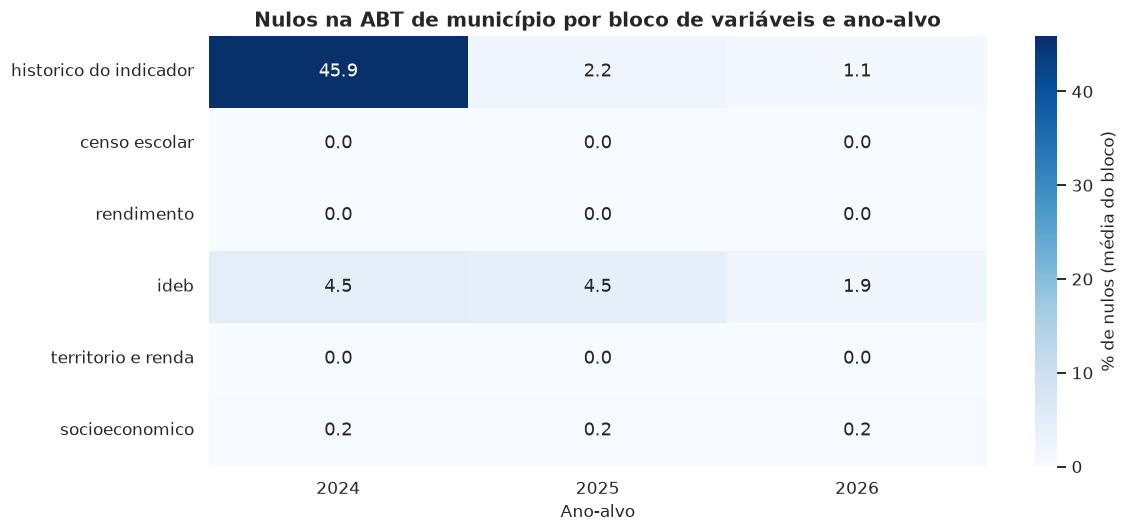

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
ordem_blocos = list(blocos)
heat = nulos_abt.reset_index().groupby("bloco")[[2024, 2025, 2026]].mean().loc[ordem_blocos]
sns.heatmap(heat, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "% de nulos (média do bloco)"}, ax=ax)
ax.set_title("Nulos na ABT de município por bloco de variáveis e ano-alvo")
ax.set_xlabel("Ano-alvo")
ax.set_ylabel("")
salvar(fig, "01_nulos_abt_municipio")
plt.show()

In [13]:
abt_alu = carregar_abt_aluno()
resumo_alu = abt_alu.groupby("ano").agg(
    alunos=("id_aluno", "size"),
    alfabetizados_pct=("alfabetizado", lambda s: 100 * s.mean()),
    municipios=("id_municipio", "nunique"),
    escolas=("id_escola", "nunique"),
    sem_contexto_municipal_pct=("indicador_t1", lambda s: 100 * s.isna().mean()),
).round(1)
resumo_alu

,alunos,alfabetizados_pct,municipios,escolas,sem_contexto_municipal_pct
ano,,,,,
2024,1851852,59.8,5517,42328,3.2
2025,1966095,66.3,5556,43538,2.1


A ABT de aluno tem 3,8 milhões de linhas. O alvo (`alfabetizado`) está razoavelmente balanceado: 60% em 2024 e 66% em 2025. Entre 2% e 3% dos alunos estão em municípios sem indicador no ano anterior (o município não teve resultado publicado em 2023 ou 2024), e para eles o histórico é imputado no pipeline.

## 6. O que fica decidido

- **A base é real e íntegra.** Chaves únicas, faixas válidas, regra do corte de 743 respeitada em 100% dos casos e cálculo próprio batendo com o oficial em 0,02 p.p.
- **Universo do alvo do aluno:** presentes com prova preenchida. Ausentes não são "não alfabetizados", são não medidos.
- **Universo do alvo do município:** a série oficial da rede municipal, que é a que tem meta pactuada.
- **Anos:** 2024 para treino e validação (tanto no grão de aluno quanto no de município), 2025 como teste temporal aberto uma única vez, 2026 só para projeção.
- **Variáveis do histórico com dois anos de defasagem** ficam fora do modelo principal, por só existirem a partir de 2025.
- **Nulos** vão para imputação dentro do pipeline, nunca antes do split.

O próximo notebook faz a análise exploratória e formula as hipóteses que vão orientar o desenho do pipeline.